# Activation Lab — run explorer

Load a completed run and explore its captured activations. Set `RUN_DIR` below to a directory produced by `activation-lab run`.

In [19]:
from pathlib import Path
from activation_lab.view import Run

RUN_DIR = sorted(Path("../runs").glob("*"))  # most recent run

# run = Run(RUN_DIR)
# run.summary()

SOURCES = [
    "hidden_in",
    "hidden_out",
    "q",
    "k",
    "v",
    "attn_out",
    "attn_weights",
    "mlp_gate",
    "mlp_up",
    "mlp_up",
    "mlp_act",
    "mlp_down_in",
    "mlp_down_out",
]

RUN_DIR

[PosixPath('../runs/.DS_Store'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T06-13-21Z'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T06-31-13Z'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T07-05-30Z'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T07-20-50Z'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T07-21-04Z'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T07-27-07Z'),
 PosixPath('../runs/qwen_basic_smoke_2026-04-22T07-30-56Z')]

In [20]:
run_1 = Run(str(RUN_DIR[1]))
run_2 = Run(str(RUN_DIR[2]))

In [21]:
print("Run 1")
run_1.summary()

Run 1


{'model': 'Qwen/Qwen1.5-0.5B',
 'num_layers': 24,
 'hidden_size': 1024,
 'device': 'mps',
 'num_steps': 8,
 'generated': 'The capital of France is Paris.<|im_end|>',
 'prompt': '<|im_start|>system\nYou are a helpful assistant<|im_end|>\n<|im_start|>user\nWhat is the capital of France?<|im_end|>\n<|im_start|>assistant\n'}

In [22]:
print("Run 2")
run_2.summary()

Run 2


{'model': 'Qwen/Qwen1.5-0.5B',
 'num_layers': 24,
 'hidden_size': 1024,
 'device': 'mps',
 'num_steps': 8,
 'generated': 'The capital of Romania is Bucharest.',
 'prompt': '<|im_start|>system\nYou are a helpful assistant<|im_end|>\n<|im_start|>user\nWhat is the capital of Romania?<|im_end|>\n<|im_start|>assistant\n'}

---
## Initial-state comparison

The **initial state** is the model's internal state at the moment it is about to generate the first token.
This corresponds to the **prefill step (step 0), position −1** (the last prompt token).

Taking position −1 makes the comparison independent of prompt length.
Looking only at step 0 makes it independent of how many tokens were generated.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

RESIDUAL_SOURCES = ["hidden_in", "hidden_out", "attn_out", "mlp_down_out"]

def initial_state(run: Run, sources=RESIDUAL_SOURCES) -> dict:
    """Return {source: (num_layers, hidden_size)} float32 arrays.

    Loads only the prefill step (step 0) and slices position -1 so the
    result is independent of prompt length and output length.
    """
    with run.load_npz(0) as npz:
        result = {}
        for src in sources:
            vecs = [
                np.asarray(npz[f"layer_{layer:02d}/{src}"], dtype=np.float32)[0, -1, :]
                for layer in range(run.num_layers)
            ]
            result[src] = np.stack(vecs)  # (num_layers, hidden_size)
    return result

In [24]:
states_1 = initial_state(run_1)
states_2 = initial_state(run_2)

layers = np.arange(run_1.num_layers)
label_1 = run_1.summary()["generated"][:25] + "…"
label_2 = run_2.summary()["generated"][:25] + "…"

print(f"run_1 → '{label_1}'")
print(f"run_2 → '{label_2}'")
print(f"Extracted {len(RESIDUAL_SOURCES)} sources × {run_1.num_layers} layers")

run_1 → 'The capital of France is …'
run_2 → 'The capital of Romania is…'
Extracted 4 sources × 24 layers


### Parameters
Change `SOURCE` and `LAYER` here; re-run the cells below.

In [25]:
SOURCE = "hidden_out"  # one of RESIDUAL_SOURCES
LAYER  = None          # int (0 – num_layers-1) to zoom into one layer, None for all layers

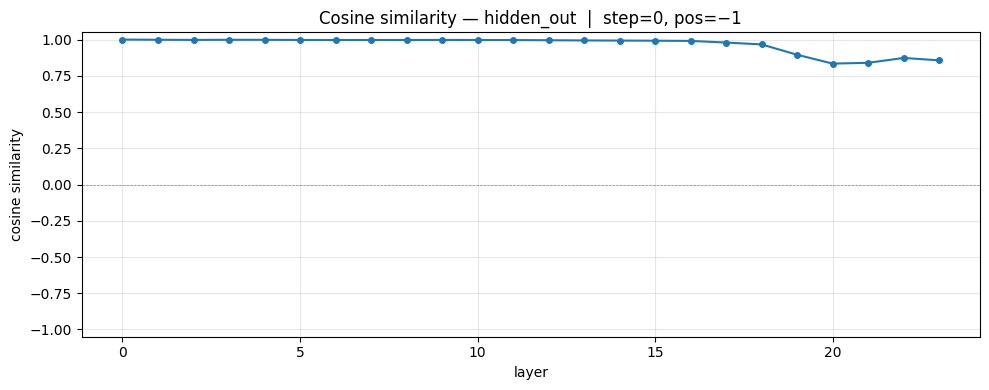

In [26]:
s1, s2 = states_1[SOURCE], states_2[SOURCE]  # (num_layers, H)

cos_all = np.array([
    np.dot(s1[l], s2[l]) / (norm(s1[l]) * norm(s2[l]) + 1e-8)
    for l in layers
])

if LAYER is None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, cos_all, marker="o", markersize=4, linewidth=1.5)
    ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.4)
    ax.set_xlabel("layer")
    ax.set_ylabel("cosine similarity")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, cos_all, marker="o", markersize=4, linewidth=1.5, alpha=0.4, color="steelblue")
    ax.axvline(LAYER, color="crimson", lw=1.5, ls="--", label=f"layer {LAYER}  cos={cos_all[LAYER]:.3f}")
    ax.scatter([LAYER], [cos_all[LAYER]], color="crimson", zorder=5, s=60)
    ax.set_xlabel("layer")
    ax.set_ylabel("cosine similarity")
    ax.legend()

ax.set_title(f"Cosine similarity — {SOURCE}  |  step=0, pos=−1")
ax.set_ylim(-1.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

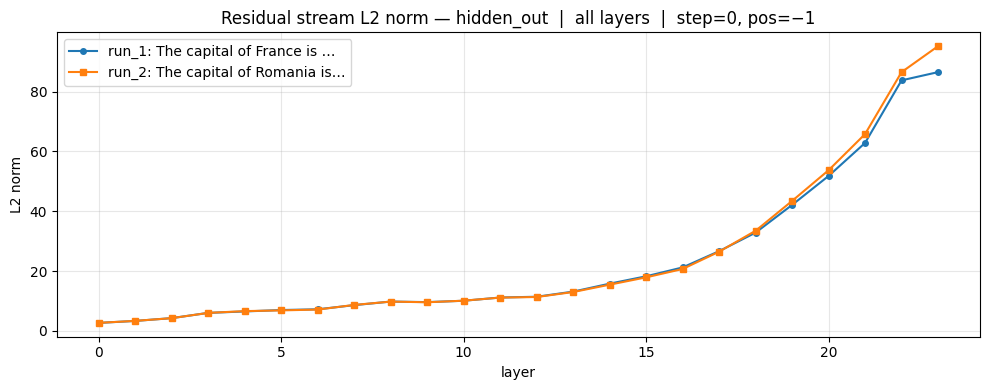

In [27]:
norms_1 = norm(states_1[SOURCE], axis=-1)  # (num_layers,)
norms_2 = norm(states_2[SOURCE], axis=-1)

if LAYER is None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, norms_1, marker="o", markersize=4, label=f"run_1: {label_1}")
    ax.plot(layers, norms_2, marker="s", markersize=4, label=f"run_2: {label_2}")
    ax.set_xlabel("layer")
    ax.set_ylabel("L2 norm")
else:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar(["run_1", "run_2"], [norms_1[LAYER], norms_2[LAYER]], color=["steelblue", "darkorange"])
    ax.set_ylabel("L2 norm")

layer_str = f"layer {LAYER}" if LAYER is not None else "all layers"
ax.set_title(f"Residual stream L2 norm — {SOURCE}  |  {layer_str}  |  step=0, pos=−1")
ax.legend() if LAYER is None else None
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

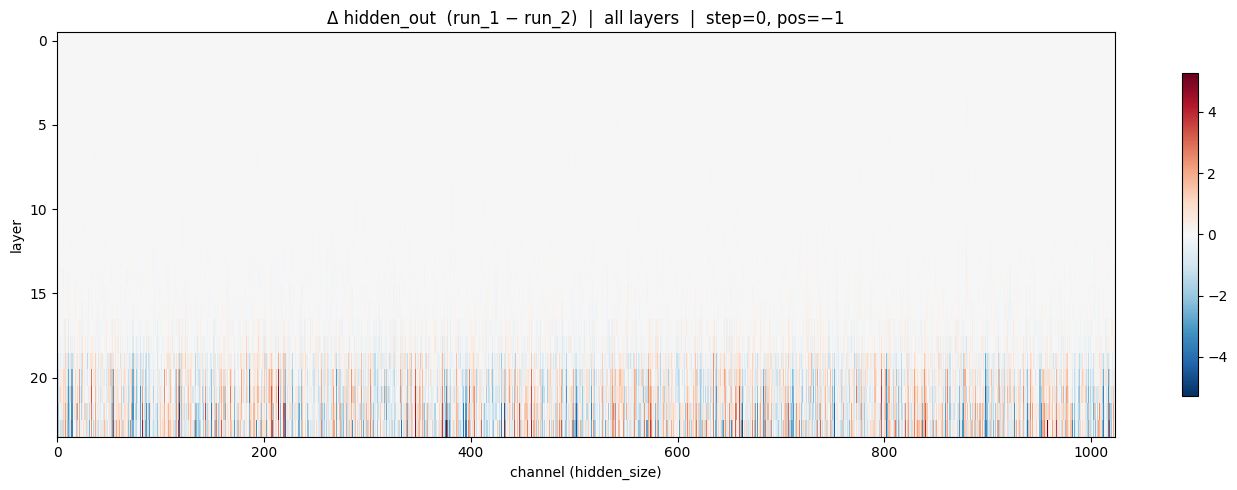

In [28]:
diff = states_1[SOURCE] - states_2[SOURCE]  # (num_layers, hidden_size)

if LAYER is None:
    vmax = float(np.abs(diff).max()) or 1.0
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(diff, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
    ax.set_xlabel("channel (hidden_size)")
    ax.set_ylabel("layer")
    plt.colorbar(im, ax=ax, shrink=0.8)
else:
    row = diff[LAYER]  # (hidden_size,)
    vmax = float(np.abs(row).max()) or 1.0
    fig, ax = plt.subplots(figsize=(14, 3))
    channels = np.arange(len(row))
    ax.bar(channels, row, color=np.where(row >= 0, "steelblue", "crimson"), width=1.0)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("channel (hidden_size)")
    ax.set_ylabel("run_1 − run_2")

layer_str = f"layer {LAYER}" if LAYER is not None else "all layers"
ax.set_title(f"Δ {SOURCE}  (run_1 − run_2)  |  {layer_str}  |  step=0, pos=−1")
plt.tight_layout()
plt.show()

Overall MAE (all layers): 0.2116


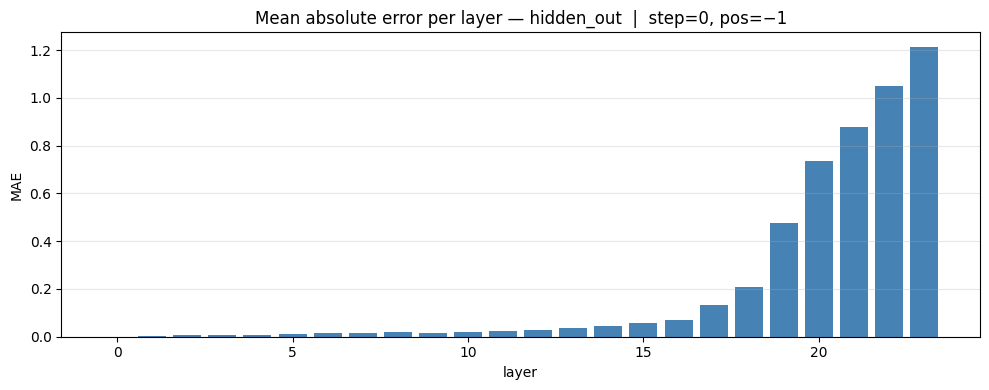

In [29]:
diff = states_1[SOURCE] - states_2[SOURCE]  # (num_layers, hidden_size)
mae_per_layer = np.abs(diff).mean(axis=-1)  # (num_layers,)

if LAYER is None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(layers, mae_per_layer, color="steelblue")
    ax.set_xlabel("layer")
    ax.set_ylabel("MAE")
    ax.set_title(f"Mean absolute error per layer — {SOURCE}  |  step=0, pos=−1")
    ax.grid(True, alpha=0.3, axis="y")
    print(f"Overall MAE (all layers): {mae_per_layer.mean():.4f}")
else:
    mae = float(mae_per_layer[LAYER])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar([f"layer {LAYER}"], [mae], color="steelblue")
    ax.set_ylabel("MAE")
    ax.set_title(f"Mean absolute error — {SOURCE}  |  layer {LAYER}  |  step=0, pos=−1")
    ax.grid(True, alpha=0.3, axis="y")
    print(f"MAE layer {LAYER}: {mae:.4f}")

plt.tight_layout()
plt.show()

---
## Multi-source initial-state comparison

The cells below evaluate **all residual sources at once** so you can see where the two runs diverge most across the whole network.

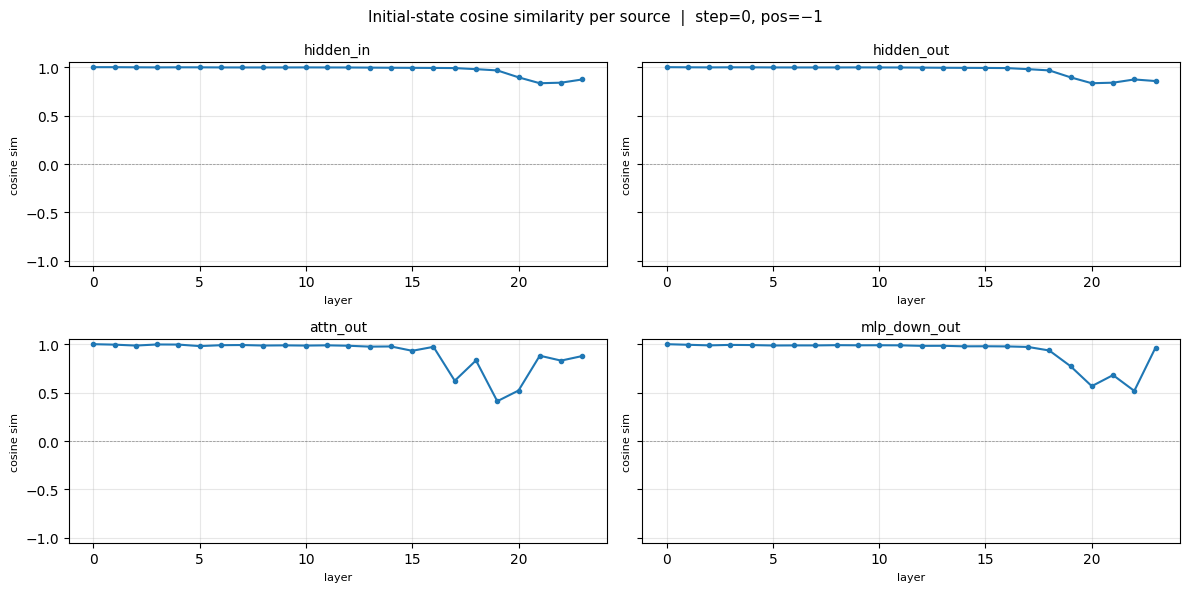

In [30]:
# --- Multi-source cosine-similarity grid ---
# One subplot per residual source; both runs share the same y-axis scale.

n_sources = len(RESIDUAL_SOURCES)
ncols = 2
nrows = (n_sources + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3), sharey=True)
axes_flat = axes.flatten()

for ax, src in zip(axes_flat, RESIDUAL_SOURCES):
    s1, s2 = states_1[src], states_2[src]
    cos = np.array([
        np.dot(s1[l], s2[l]) / (norm(s1[l]) * norm(s2[l]) + 1e-8)
        for l in layers
    ])
    ax.plot(layers, cos, marker="o", markersize=3, linewidth=1.5)
    ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.4)
    ax.set_title(src, fontsize=10)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("layer", fontsize=8)
    ax.set_ylabel("cosine sim", fontsize=8)

# Hide any unused subplots
for ax in axes_flat[n_sources:]:
    ax.set_visible(False)

fig.suptitle(f"Initial-state cosine similarity per source  |  step=0, pos=−1", fontsize=11)
plt.tight_layout()
plt.show()

In [31]:
# --- Summary stats table ---
# Mean cosine similarity and mean MAE across layers, for each source.

import pandas as pd

rows = []
for src in RESIDUAL_SOURCES:
    s1, s2 = states_1[src], states_2[src]
    cos_vals = np.array([
        np.dot(s1[l], s2[l]) / (norm(s1[l]) * norm(s2[l]) + 1e-8)
        for l in layers
    ])
    mae_vals = np.abs(s1 - s2).mean(axis=-1)
    rows.append({
        "source": src,
        "mean_cosine": round(float(cos_vals.mean()), 4),
        "min_cosine": round(float(cos_vals.min()), 4),
        "most_divergent_layer": int(cos_vals.argmin()),
        "mean_MAE": round(float(mae_vals.mean()), 4),
        "max_MAE_layer": int(mae_vals.argmax()),
    })

df_summary = pd.DataFrame(rows).set_index("source")
df_summary

,mean_cosine,min_cosine,most_divergent_layer,mean_MAE,max_MAE_layer
source,,,,,
hidden_in,0.9720,0.8343,21,0.1610,23
hidden_out,0.9660,0.8343,20,0.2116,23
attn_out,0.9040,0.4110,19,0.0667,22
mlp_down_out,0.9245,0.5175,22,0.1008,22


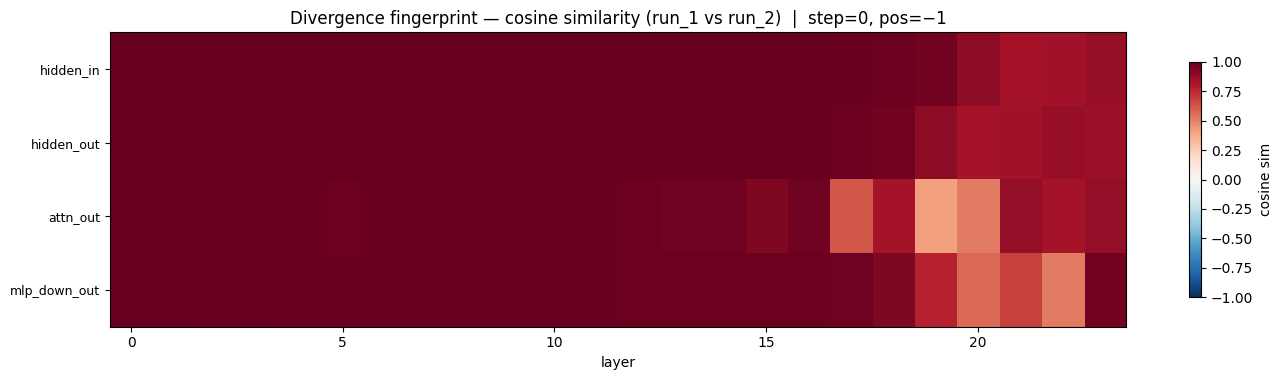

In [32]:
# --- Divergence fingerprint heatmap ---
# (sources × layers) matrix of cosine similarity.
# Dark = similar, bright red/blue = divergent.

cos_matrix = np.zeros((len(RESIDUAL_SOURCES), run_1.num_layers))
for i, src in enumerate(RESIDUAL_SOURCES):
    s1, s2 = states_1[src], states_2[src]
    cos_matrix[i] = [
        np.dot(s1[l], s2[l]) / (norm(s1[l]) * norm(s2[l]) + 1e-8)
        for l in layers
    ]

fig, ax = plt.subplots(figsize=(14, len(RESIDUAL_SOURCES) * 0.6 + 1.5))
im = ax.imshow(cos_matrix, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
ax.set_yticks(range(len(RESIDUAL_SOURCES)))
ax.set_yticklabels(RESIDUAL_SOURCES, fontsize=9)
ax.set_xlabel("layer")
ax.set_title("Divergence fingerprint — cosine similarity (run_1 vs run_2)  |  step=0, pos=−1")
plt.colorbar(im, ax=ax, shrink=0.8, label="cosine sim")
plt.tight_layout()
plt.show()